In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import cross_validate, KFold

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)


/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [6]:
df = pd.read_csv("cars.csv")
print("Dataset ölçüsü:", df.shape)
display(df.head())

Dataset ölçüsü: (653721, 56)


,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.0,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.6,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.0,AZN,Şəmi,NaN,507687355.0,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.7,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.0,AZN,NaN,Lada Azərbaycan,554092445.0,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.0,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.0,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.0,USD,Anar,NaN,502126242.0,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.0,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.0,AZN,Babək,NaN,774999004.0,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyo

In [7]:
print(df.columns.tolist())

['id_x', 'car_rel_url_x', 'datetime_scrape', 'name', 'price_x', 'currency_x', 'datetime_product', 'city', 'day', 'hour', 'attributes', 'production_year', 'engine_displacement_num', 'engine_displacement_unit', 'kilometrage_num', 'kilometrage_unit', 'barter', 'loan', 'salon', 'spare_parts', 'vip', 'featured', 'img_url', 'id_y', 'cars_id', 'car_rel_url_y', 'datetime', 'description', 'price_y', 'currency_y', 'owner_name', 'shop_name', 'phone', 'updated', 'views', 'vin', 'car_details_id_x', 'Ban növü', 'Buraxılış ili', 'Hansı bazar üçün yığılıb', 'Marka', 'Model', 'Mühərrik', 'Qəzalı', 'Rəng', 'Sahiblər', 'Sürətlər qutusu', 'Vəziyyəti', 'Yeni', 'Yerlərin sayı', 'Yürüş', 'Ötürücü', 'Şəhər', 'car_details_id_y', 'car_rel_url', 'extra_info']


In [8]:
df["price_x"] = pd.to_numeric(
    df["price_x"],
    errors="coerce"
)

print("price_x tipi:", df["price_x"].dtype)

print(
    "price_x boş dəyərlər:",
    df["price_x"].isna().sum()
)

price_x tipi: float64
price_x boş dəyərlər: 0


**CHECKPOINT 1** — TRAIN / TEST BÖLGÜSÜ

In [9]:
features = [
    "production_year",
    "engine_displacement_num",
    "kilometrage_num",
    "views",
    "city",
    "Marka",
    "Model",
    "Ban növü",
    "Mühərrik",
    "Qəzalı",
    "Rəng",
    "Sahiblər",
    "Sürətlər qutusu",
    "Vəziyyəti",
    "Yeni",
    "Yerlərin sayı",
    "Yürüş",
    "Ötürücü"
]

target = "price_x"

In [10]:
model_df = df[
    features + [target]
].copy()

model_df = model_df[
    model_df[target].notna()
    &
    (model_df[target] > 0)
].copy()

print(
    "Model dataset ölçüsü:",
    model_df.shape
)

Model dataset ölçüsü: (653721, 19)


In [11]:
X = model_df[features]

y = model_df[target]

print("X ölçüsü:", X.shape)

print("y ölçüsü:", y.shape)

X ölçüsü: (653721, 18)
y ölçüsü: (653721,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train X:", X_train.shape)

print("Test X:", X_test.shape)

print("Train y:", y_train.shape)

print("Test y:", y_test.shape)

Train X: (522976, 18)
Test X: (130745, 18)
Train y: (522976,)
Test y: (130745,)


**CHECKPOINT 2** — PREPROCESSING PIPELINE

In [13]:
numeric_features = [
    "production_year",
    "engine_displacement_num",
    "kilometrage_num",
    "views"
]

categorical_features = [
    "city",
    "Marka",
    "Model",
    "Ban növü",
    "Mühərrik",
    "Qəzalı",
    "Rəng",
    "Sahiblər",
    "Sürətlər qutusu",
    "Vəziyyəti",
    "Yeni",
    "Yerlərin sayı",
    "Yürüş",
    "Ötürücü"
]

print(
    "Numeric feature sayı:",
    len(numeric_features)
)

print(
    "Categorical feature sayı:",
    len(categorical_features)
)

Numeric feature sayı: 4
Categorical feature sayı: 14


In [14]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [15]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline hazırdır.")

Preprocessing pipeline hazırdır.


**CHECKPOINT 3** — 2 FƏRQLİ MODEL

In [17]:
linear_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

In [18]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=15,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [19]:
print("Linear Regression öyrədilir...")

linear_pipeline.fit(
    X_train,
    y_train
)

print("Linear Regression hazırdır.")

Linear Regression öyrədilir...
Linear Regression hazırdır.


In [21]:
print("Random Forest öyrədilir...")

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=30,
                max_depth=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest hazırdır.")

Random Forest öyrədilir...
Random Forest hazırdır.


**CHECKPOINT 4** — METRİKLƏR

In [22]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):
    
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(
        y_test,
        predictions
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
    
    r2 = r2_score(
        y_test,
        predictions
    )
    
    print(model_name)
    print("-" * 40)
    
    print(
        f"MAE: {mae:,.2f} AZN"
    )
    
    print(
        f"RMSE: {rmse:,.2f} AZN"
    )
    
    print(
        f"R²: {r2:.4f}"
    )
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [23]:
linear_results = evaluate_model(
    linear_pipeline,
    X_test,
    y_test,
    "Linear Regression"
)

Linear Regression
----------------------------------------
MAE: 4,478.45 AZN
RMSE: 21,391.03 AZN
R²: 0.4307


In [24]:
rf_results = evaluate_model(
    rf_pipeline,
    X_test,
    y_test,
    "Random Forest"
)

Random Forest
----------------------------------------
MAE: 4,944.15 AZN
RMSE: 8,798.30 AZN
R²: 0.9037


In [25]:
results = pd.DataFrame(
    [
        linear_results,
        rf_results
    ]
)

display(results)

,Model,MAE,RMSE,R2
0,Linear Regression,4478.454871,21391.027942,0.430714
1,Random Forest,4944.145955,8798.298628,0.903692


In [26]:
best_model_name = (
    results
    .sort_values("RMSE")
    .iloc[0]["Model"]
)

print(
    "Ən yaxşı model:",
    best_model_name
)

Ən yaxşı model: Random Forest


In [27]:
if best_model_name == "Linear Regression":
    best_model = linear_pipeline
else:
    best_model = rf_pipeline


predictions = best_model.predict(
    X_test
)

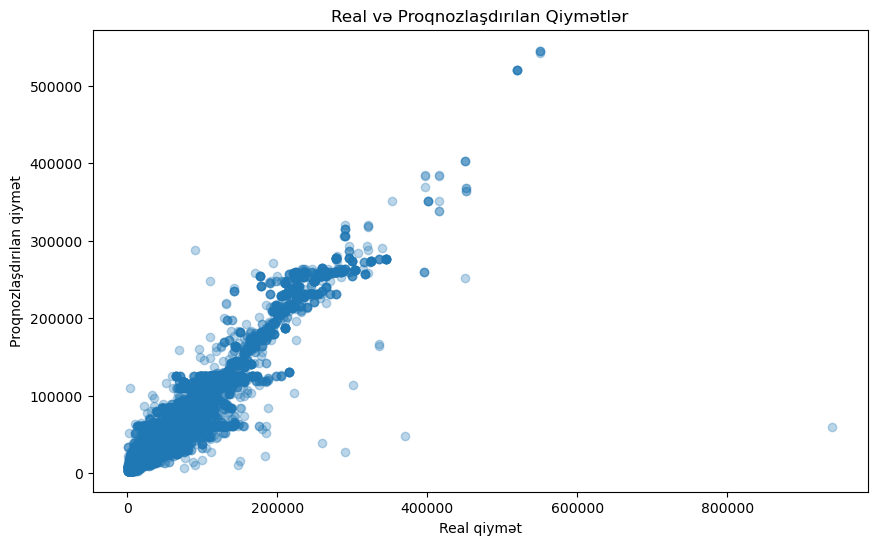

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.3
)

plt.xlabel("Real qiymət")

plt.ylabel(
    "Proqnozlaşdırılan qiymət"
)

plt.title(
    "Real və Proqnozlaşdırılan Qiymətlər"
)

plt.show()

**CHECKPOINT 5** — CROSS-VALIDATION

In [29]:
cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [32]:
linear_cv = cross_validate(
    linear_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib

In [39]:
rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [40]:
cv_results = pd.DataFrame(
    {
        "Model": [
            "Linear Regression",
            "Random Forest"
        ],
        
        "CV MAE": [
            -linear_cv["test_MAE"].mean(),
            -rf_cv["test_MAE"].mean()
        ],
        
        "CV RMSE": [
            -linear_cv["test_RMSE"].mean(),
            -rf_cv["test_RMSE"].mean()
        ],
        
        "CV R²": [
            linear_cv["test_R2"].mean(),
            rf_cv["test_R2"].mean()
        ]
    }
)

display(cv_results)

,Model,CV MAE,CV RMSE,CV R²
0,Linear Regression,4675.205073,22520.308885,0.383720
1,Random Forest,4943.554654,8552.193776,0.911568


**CHECKPOINT 6** — FEATURE IMPORTANCE

In [41]:
rf_model = (
    rf_pipeline
    .named_steps["model"]
)

feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": importances
    }
)

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    feature_importance.head(20)
)

,Feature,Importance
1,num__engine_displacement_num,0.445774
0,num__production_year,0.293306
2,num__kilometrage_num,0.057527
39535,cat__Ötürücü_Tam,0.032022
2069,cat__Model_Range Rover,0.027078
9720,cat__Yerlərin sayı_7,0.019580
9704,cat__Sürətlər qutusu_Mexaniki,0.019049
195,cat__Marka_Mercedes,0.006989
226,cat__Marka_Rolls-Royce,0.006753
2237,cat__Model_Spectre,0.006126


In [42]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance")
)

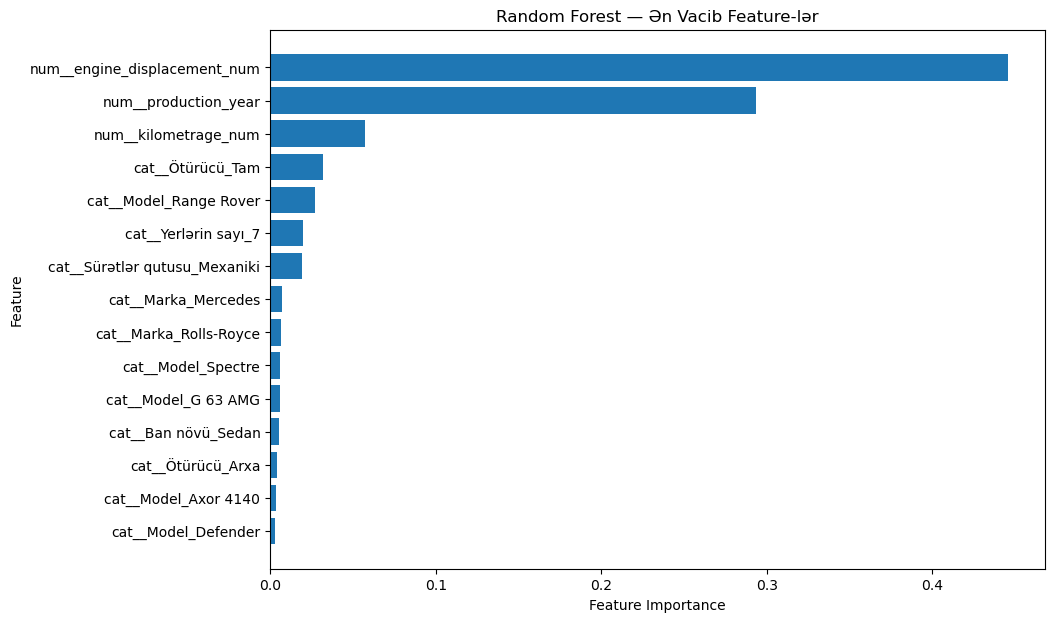

In [37]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.title(
    "Random Forest — Ən Vacib Feature-lər"
)

plt.show()

In [43]:
numeric_importance = feature_importance[
    feature_importance["Feature"].str.startswith(
        "num__"
    )
].copy()

numeric_importance["Feature"] = (
    numeric_importance["Feature"]
    .str.replace(
        "num__",
        "",
        regex=False
    )
)

display(
    numeric_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

,Feature,Importance
1,engine_displacement_num,0.445774
0,production_year,0.293306
2,kilometrage_num,0.057527
3,views,0.000617


### Feature Importance Interpretation

Feature importance nəticələrinə əsasən avtomobil qiymətinin proqnozlaşdırılmasında
ən əhəmiyyətli dəyişənlər arasında Model, Marka, Buraxılış ili və Yürüş
yer alır.

Bu nəticə onu göstərir ki, avtomobilin hansı marka və model olması,
istehsal ili və istifadə olunma səviyyəsi qiymətin müəyyənləşməsində
əhəmiyyətli rol oynayır.

Random Forest-də yüksək importance dəyəri həmin feature-in modelin
proqnozlarına daha çox töhfə verdiyini göstərir. Lakin bu, həmin
feature-in qiymətə birbaşa səbəb olduğunu ifadə etmir.

## Final Business Interpretation

Bu layihədə avtomobillərin qiymətini proqnozlaşdırmaq üçün reqressiya modellərindən istifadə edilmişdir.

Train/test bölgüsü preprocessing-dən əvvəl aparılmış və data leakage probleminin qarşısı alınmışdır.

Numeric dəyişənlər üçün missing values median ilə doldurulmuş və StandardScaler tətbiq edilmişdir. Categorical dəyişənlər isə most frequent üsulu ilə doldurulmuş və OneHotEncoder ilə çevrilmişdir.

Linear Regression və Random Forest Regressor modelləri qurulmuş və MAE, RMSE və R² metrikləri ilə müqayisə edilmişdir.

Cross-validation vasitəsilə modellərin müxtəlif data bölgülərində performansı yoxlanılmışdır.

Feature importance analizi vasitəsilə avtomobil qiymətinin proqnozlaşdırılmasında daha əhəmiyyətli xüsusiyyətlər müəyyən edilmişdir.

Biznes baxımından bu model avtomobillərin ilkin qiymətləndirilməsi, uyğun qiymət aralığının müəyyənləşdirilməsi və satış strategiyasının hazırlanmasına kömək edə bilər.

Lakin modelin nəticəsi real bazar qiymətinin tam əvəzi deyil. Marka, model, buraxılış ili, yürüş, avtomobilin vəziyyəti və digər faktorlar da qiymətə təsir göstərə bilər.